# E37 — O relógio e a causa

A ordem que o capítulo da queda conjunta deixou de pé, lida como causa pelo leitor --- e as três
contas que separam o que ela é do que parece: **o relógio** (a ordem sobrevive ao alinhamento
declarado?), **o canal impossível** (um par sem canal repete a assinatura?) e **o terceiro comum**
(um par sem seta nenhuma a alcança?). Critérios declarados na docstring do construtor; tudo com
dispersão junto.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from frevolab import dados, dependencia, graficos, mudanca, relogio

SEMENTE = 104          # <- brinque com:
NULOS = 40
ATRASOS = (-2, -1, 0, 1, 2)
RHOS = (0.5, 0.8, 0.95, 0.999)

preco_sp = dados.carregar_serie("sp500.csv")
preco_ib = dados.carregar_serie("ibov.csv")
preco_bt = dados.carregar_serie("btc.csv")
retornos_sp = preco_sp.pct_change().dropna()
retornos_ib = preco_ib.pct_change().dropna()
retornos_bt = preco_bt.pct_change().dropna()
print("sp %d | ibov %d | btc %d dias" % (retornos_sp.size, retornos_ib.size, retornos_bt.size))

sp 6718 | ibov 6620 | btc 4387 dias


In [2]:
# O par real, na varredura de menos dois a mais dois dias, com o nulo deslocado igual.
varredura_real = relogio.varredura(retornos_sp, retornos_ib, atrasos=ATRASOS, nulos=NULOS, sementes=SEMENTE)
for atraso in ATRASOS:
    caixa = varredura_real[atraso]
    print("atraso %+d | assimetria %+.4f | nulo %+.4f (disp %.4f) | %+.2f desvios | %d dias" % (
        atraso, caixa["assimetria"], caixa["nulo_media"], caixa["nulo_dispersao"],
        caixa["desvios"], caixa["dias"]))

atraso -2 | assimetria -0.3091 | nulo -0.3342 (disp 0.0944) | +0.27 desvios | 6450 dias
atraso -1 | assimetria -0.2762 | nulo -0.3512 (disp 0.1088) | +0.69 desvios | 6450 dias
atraso +0 | assimetria +0.2727 | nulo +0.0287 (disp 0.1198) | +2.04 desvios | 6450 dias
atraso +1 | assimetria +0.5536 | nulo +0.3728 (disp 0.0755) | +2.39 desvios | 6450 dias
atraso +2 | assimetria +0.5686 | nulo +0.3593 (disp 0.0700) | +2.99 desvios | 6450 dias


In [3]:
# O canal impossível: Bitcoin contra cada um, mesmo instrumento, mesmo nulo, no atraso zero.
canal_sp = relogio.varredura(retornos_bt, retornos_sp, atrasos=(0,), nulos=NULOS, sementes=SEMENTE + 100)[0]
canal_ib = relogio.varredura(retornos_bt, retornos_ib, atrasos=(0,), nulos=NULOS, sementes=SEMENTE + 200)[0]
print("btc x sp   | assimetria %+.4f | nulo %+.4f (disp %.4f) | %+.2f desvios | %d dias" % (
    canal_sp["assimetria"], canal_sp["nulo_media"], canal_sp["nulo_dispersao"], canal_sp["desvios"], canal_sp["dias"]))
print("btc x ibov | assimetria %+.4f | nulo %+.4f (disp %.4f) | %+.2f desvios | %d dias" % (
    canal_ib["assimetria"], canal_ib["nulo_media"], canal_ib["nulo_dispersao"], canal_ib["desvios"], canal_ib["dias"]))

btc x sp   | assimetria -0.0345 | nulo -0.0081 (disp 0.1721) | -0.15 desvios | 3019 dias
btc x ibov | assimetria +0.1034 | nulo -0.0189 (disp 0.1298) | +0.94 desvios | 2980 dias


In [4]:
# O terceiro comum: sem seta nenhuma, com as margens do par real, varrendo a fração do terceiro.
comuns_real = retornos_sp.index.intersection(retornos_ib.index)
N_TERCEIRO = comuns_real.size
SIGMA_SP = float(retornos_sp.loc[comuns_real].std())
SIGMA_IB = float(retornos_ib.loc[comuns_real].std())
print("margens do par real: sp %.4f | ibov %.4f | n %d" % (SIGMA_SP, SIGMA_IB, N_TERCEIRO))
ruler = varredura_real[0]
terceiro = {}
for rho in RHOS:
    semente_mundo = SEMENTE + 300 + int(rho * 1000)
    x, y = relogio.terceiro_comum(N_TERCEIRO, np.random.default_rng(semente_mundo), rho, SIGMA_SP, SIGMA_IB)
    pa = dependencia.rompimentos(pd.Series(x, index=comuns_real))
    pb = dependencia.rompimentos(pd.Series(y, index=comuns_real))
    assim = dependencia.episodios_dirigidos(pa, pb)["assimetria"]
    desvios = (assim - ruler["nulo_media"]) / ruler["nulo_dispersao"]
    terceiro[rho] = {"assimetria": float(assim), "desvios": float(desvios)}
    print("rho %.3f | assimetria %+.4f | %+.2f desvios na regua do par real" % (rho, assim, desvios))

margens do par real: sp 0.0121 | ibov 0.0169 | n 6450
rho 0.500 | assimetria +0.0127 | -0.13 desvios na regua do par real
rho 0.800 | assimetria +0.0769 | +0.40 desvios na regua do par real
rho 0.950 | assimetria -0.0732 | -0.85 desvios na regua do par real
rho 0.999 | assimetria +0.0000 | -0.24 desvios na regua do par real


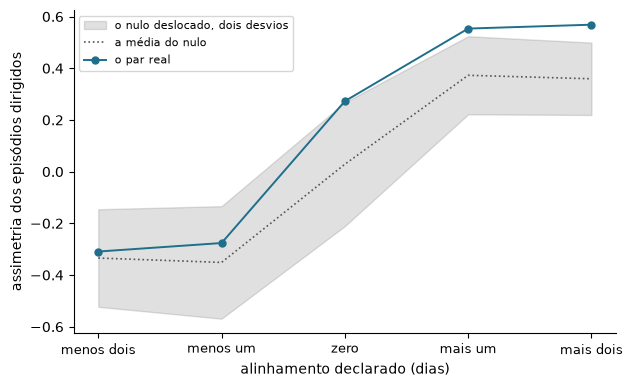

In [5]:
# Figura 1: a varredura do relógio --- a assimetria contra o atraso, com a faixa de dois desvios
# do nulo deslocado em cada ponto.
fig, ax = plt.subplots(figsize=(7.0, 4.2))
xs = np.array(ATRASOS)
ys = [varredura_real[a]["assimetria"] for a in ATRASOS]
med = [varredura_real[a]["nulo_media"] for a in ATRASOS]
disp = [varredura_real[a]["nulo_dispersao"] for a in ATRASOS]
ax.fill_between(xs, np.array(med) - 2 * np.array(disp), np.array(med) + 2 * np.array(disp),
                color="#555555", alpha=0.18, label="o nulo deslocado, dois desvios")
ax.plot(xs, med, ":", color="#555555", lw=1.2, label="a média do nulo")
ax.plot(xs, ys, "o-", color="#1f6f8b", lw=1.4, ms=5, label="o par real")
ax.set_xticks(ATRASOS)
ax.set_xticklabels(["menos dois", "menos um", "zero", "mais um", "mais dois"], fontsize=9)
ax.set_xlabel("alinhamento declarado (dias)")
ax.set_ylabel("assimetria dos episódios dirigidos")
ax.legend(fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E37_relogio", 1)
plt.show()

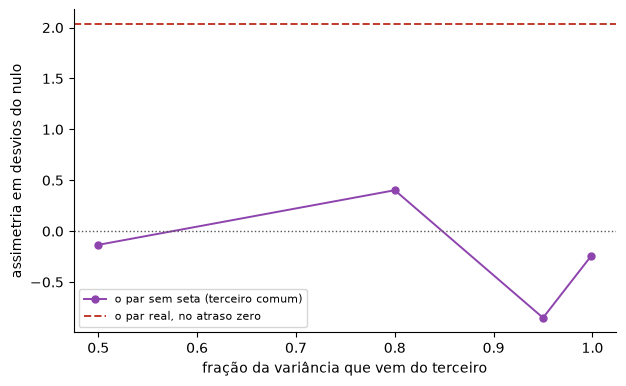

In [6]:
# Figura 2: o terceiro comum --- a assinatura (em desvios na régua do par real) contra a fração do
# terceiro, com a linha do par real marcada.
fig, ax = plt.subplots(figsize=(7.0, 4.2))
xs = np.array(RHOS)
ys = [terceiro[r]["desvios"] for r in RHOS]
ax.plot(xs, ys, "o-", color="#8e44ad", lw=1.4, ms=5, label="o par sem seta (terceiro comum)")
ax.axhline(varredura_real[0]["desvios"], color="#c0392b", ls="--", lw=1.4,
           label="o par real, no atraso zero")
ax.axhline(0.0, color="#555555", ls=":", lw=1.0)
ax.set_xlabel("fração da variância que vem do terceiro")
ax.set_ylabel("assimetria em desvios do nulo")
ax.legend(fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E37_relogio", 2)
plt.show()

In [7]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) a faixa cinza ACOMPANHA o alinhamento (o viés do instrumento anda com o deslocamento: media
#    do nulo de -0,33 no menos dois a +0,37 no mais dois); a curva azul cruza a faixa no menos um
#    (o relógio declarado) e sai por cima no mais um e mais dois; o eixo vai de -0,6 a 0,6 porque
#    a assimetria troca de sinal;
# 2) a curva roxa do par sem seta vive toda dentro de +-0,5 desvio e a linha tracejada vermelha do
#    par real esta no alto do eixo (+2,0): nenhuma fracao do terceiro alcanc; a o eixo x comeca em
#    0,5 e termina em 1,0.

In [8]:
# O que sai do laboratório e o que o livro cita.
nomes_atraso = {-2: "menos_dois", -1: "menos_um", 0: "zero", 1: "um", 2: "dois"}
nomes_rho = {0.5: "meio", 0.8: "alto", 0.95: "muito_alto", 0.999: "quase_um"}
resultado = {"relogio_nulos": int(NULOS)}
for atraso in ATRASOS:
    caixa = varredura_real[atraso]
    resultado["relogio_%s_assimetria" % nomes_atraso[atraso]] = round(caixa["assimetria"], 4)
    resultado["relogio_%s_nulo" % nomes_atraso[atraso]] = round(caixa["nulo_media"], 4)
    resultado["relogio_%s_nulo_dispersao" % nomes_atraso[atraso]] = round(caixa["nulo_dispersao"], 4)
    resultado["relogio_%s_desvios" % nomes_atraso[atraso]] = round(caixa["desvios"], 2)
    resultado["relogio_%s_dias" % nomes_atraso[atraso]] = caixa["dias"]
resultado["relogio_btc_sp_assimetria"] = round(canal_sp["assimetria"], 4)
resultado["relogio_btc_sp_desvios"] = round(canal_sp["desvios"], 2)
resultado["relogio_btc_sp_dias"] = canal_sp["dias"]
resultado["relogio_btc_ibov_assimetria"] = round(canal_ib["assimetria"], 4)
resultado["relogio_btc_ibov_desvios"] = round(canal_ib["desvios"], 2)
resultado["relogio_btc_ibov_dias"] = canal_ib["dias"]
resultado["relogio_terceiro_dias"] = int(N_TERCEIRO)
resultado["relogio_terceiro_sigma_sp"] = round(SIGMA_SP, 4)
resultado["relogio_terceiro_sigma_ibov"] = round(SIGMA_IB, 4)
for rho in RHOS:
    resultado["relogio_terceiro_%s_desvios" % nomes_rho[rho]] = round(terceiro[rho]["desvios"], 2)
    resultado["relogio_terceiro_%s_assimetria" % nomes_rho[rho]] = round(terceiro[rho]["assimetria"], 4)

CITADAS_NO_LIVRO = tuple(sorted(resultado))
resultado = {k: v for k, v in resultado.items() if k in CITADAS_NO_LIVRO}
import json
from pathlib import Path
caminho = Path("lab/resultados/E37_relogio_causa.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "relogio_btc_ibov_assimetria": 0.1034,
 "relogio_btc_ibov_desvios": 0.94,
 "relogio_btc_ibov_dias": 2980,
 "relogio_btc_sp_assimetria": -0.0345,
 "relogio_btc_sp_desvios": -0.15,
 "relogio_btc_sp_dias": 3019,
 "relogio_dois_assimetria": 0.5686,
 "relogio_dois_desvios": 2.99,
 "relogio_dois_dias": 6450,
 "relogio_dois_nulo": 0.3593,
 "relogio_dois_nulo_dispersao": 0.07,
 "relogio_menos_dois_assimetria": -0.3091,
 "relogio_menos_dois_desvios": 0.27,
 "relogio_menos_dois_dias": 6450,
 "relogio_menos_dois_nulo": -0.3342,
 "relogio_menos_dois_nulo_dispersao": 0.0944,
 "relogio_menos_um_assimetria": -0.2762,
 "relogio_menos_um_desvios": 0.69,
 "relogio_menos_um_dias": 6450,
 "relogio_menos_um_nulo": -0.3512,
 "relogio_menos_um_nulo_dispersao": 0.1088,
 "relogio_nulos": 40,
 "relogio_terceiro_alto_assimetria": 0.0769,
 "relogio_terceiro_alto_desvios": 0.4,
 "relogio_terceiro_dias": 6450,
 "relogio_terceiro_meio_assimetria": 0.0127,
 "relogio_terceiro_meio_desvios": -0.13,
 "relogio_terceir